<a href="https://colab.research.google.com/github/gerryfrank10/ComputerVision/blob/main/end_to_end_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pathlib
import torch
import torch.utils.data

from torchvision import models, datasets, tv_tensors, transforms
from torchvision.transforms import ToTensor, v2

In [9]:
resnet50 = models.resnet50(pretrained=True)
type(resnet50)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 146MB/s]


torchvision.models.resnet.ResNet

In [10]:
resnet50

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [13]:
# Preprocess the image pipeline
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [14]:
# Image URLs
uris = [
    'http://images.cocodataset.org/test-stuff2017/000000024309.jpg',
    'http://images.cocodataset.org/test-stuff2017/000000028117.jpg',
    'http://images.cocodataset.org/test-stuff2017/000000006149.jpg',
    'http://images.cocodataset.org/test-stuff2017/000000004954.jpg',
]

In [15]:
from PIL import Image
import requests
from io import BytesIO

batch = []
for uri in uris:
  response = requests.get(uri)
  img = Image.open(BytesIO(response.content))
  tensor = preprocess(img)
  batch.append(tensor)
len(batch)

4

In [21]:
batch[1].shape

torch.Size([3, 224, 224])

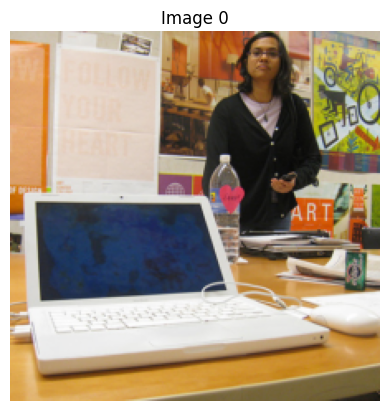

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# ImageNet normalization values (used during preprocessing)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Select the image
img = batch[0].clone()  # shape: (3, 224, 224)

# Unnormalize
img = img.permute(1, 2, 0).numpy()  # change to (224, 224, 3) and convert to NumPy
img = std * img + mean  # unnormalize
img = np.clip(img, 0, 1)  # clip values to [0, 1]

# Plot
plt.imshow(img)
plt.axis('off')
plt.title("Image 0")
plt.show()

In [28]:
batch = torch.stack(batch)
with torch.no_grad():
  outputs = resnet50(batch)
print(outputs.shape)

torch.Size([4, 1000])


In [30]:
probs = torch.nn.functional.softmax(outputs, dim=1)
print(probs.shape)

torch.Size([4, 1000])


In [61]:
top2_prob, top2_cat = torch.topk(probs, 2)
print(top2_prob)
print(top2_cat)

tensor([[0.1181, 0.1051],
        [0.2525, 0.1026],
        [0.1975, 0.1104],
        [0.1959, 0.0665]])
tensor([[620, 526],
        [935, 923],
        [752, 852],
        [104, 225]])


In [35]:
LABELS_URL = 'https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt'
imagenet_classes = requests.get(LABELS_URL).text.strip().split('\n')
imagenet_classes[:10]

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich']

In [60]:
imagenet_classes[top2_cat[0][0]]

'laptop'

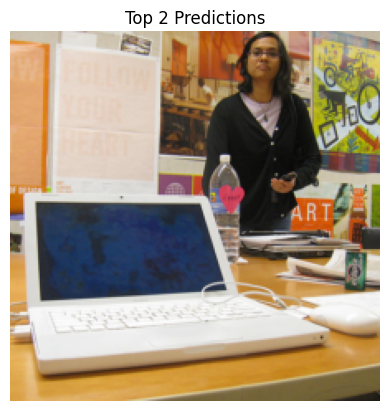

notebook: 0.4622
laptop: 0.2865


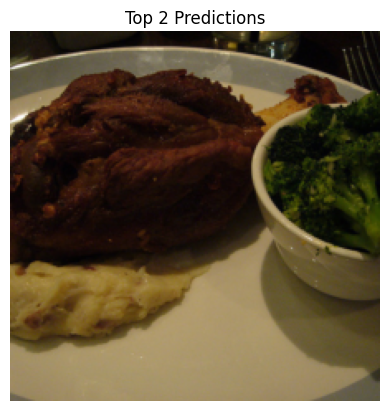

mashed potato: 0.7632
meat loaf: 0.1364


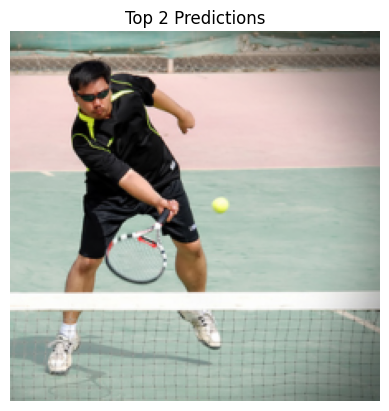

racket: 0.7656
tennis ball: 0.2338


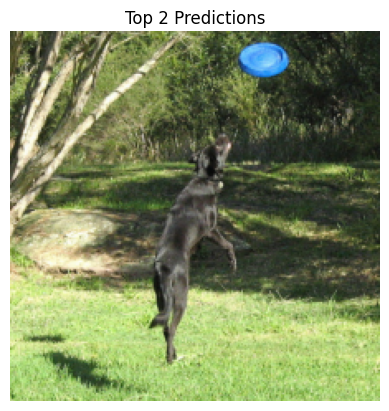

Scottish deerhound: 0.1381
Irish wolfhound: 0.1265


In [74]:
resnet50.eval() # Eval mode

for i, img in enumerate(batch):
    # Unsqueeze to make it a batch of 1: shape [1, 3, 224, 224]
    input_tensor = img.unsqueeze(0)

    # Run model prediction
    with torch.no_grad():
        output = resnet50(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        top2_prob, top2_cat = torch.topk(probabilities, 2)

    # Unnormalize and prepare image for display
    img_np = img.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # Show image
    plt.imshow(img_np)
    plt.axis('off')
    plt.title("Top 2 Predictions")
    plt.show()

    # Print top 2 predictions
    for j in range(2):
        prob = top2_prob[j].item()
        cat = top2_cat[j].item()
        print(f"{imagenet_classes[cat]}: {prob:.4f}")